# AI Multi-Stop Planner — Hybrid (Pickup + Delivery)

**Pipeline:** Gmail → LLM Parse → Geocode → ORS Optimize → Distance Matrix → Reply

**Flow:**
```
gmail_trigger → parser_agent → save_email_logs_to_sheet
    → geocode_pickup_delivery_address → route_optimization
    → ai_agent_reply → send_reply_to_gmail
```
Each node has a conditional edge to `error_handler` on failure.

In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from typing import TypedDict, Optional, List, Literal
import hashlib, logging, os, time
from datetime import datetime

load_dotenv()

logging.basicConfig(level=logging.INFO, format='%(asctime)s [%(levelname)s] %(message)s')
log = logging.getLogger(__name__)

OPENAI_API_KEY = os.getenv('OPENAI_API_KEY', '')

## Data Models

In [2]:
class StopContext(BaseModel):
    store_id: str = Field(description='Store identifier, e.g. STORE-101')
    store_name: str = Field(description='Store or company name')
    pickup_address: str = Field(description='Full pickup street address')
    delivery_address: str = Field(description='Full delivery street address')
    expected_pickup_time: Optional[str] = Field(None, description="e.g. '09:00'")
    expected_delivery_time: Optional[str] = Field(None, description="e.g. '13:00'")
    temperature_control: bool = Field(False, description='True if cold-chain required')
    collection_date: Optional[str] = Field(None, description="e.g. '2024-04-12'")


class ParsedEmailOutput(BaseModel):
    sender_name: str = Field(description='Name of the person who sent the email')
    sender_company: str = Field(description='Retailer company name')
    collection_date: Optional[str] = Field(None)
    stops: List[StopContext] = Field(description='All pickup stops in the email')



class OptimizedStop(BaseModel):
    job_id: str
    store_id: str
    store_name: str
    pickup_address: str
    delivery_address: str = ''
    latitude: float
    longitude: float
    original_sequence: int
    optimized_sequence: int
    arrival_time_seconds: int
    service_duration_seconds: int = 300
    temperature_control: bool = False

    @property
    def eta(self) -> str:
        h, rem = divmod(self.arrival_time_seconds, 3600)
        return f'{h:02d}:{rem // 60:02d}'


class RouteResult(BaseModel):
    """Holds both original-order and optimized-order metrics from /matrix."""
    original_distance_km: float
    original_duration_min: float
    original_legs: List[dict]
    optimized_distance_km: float
    optimized_duration_min: float
    optimized_legs: List[dict]

    ordered_stops: List[OptimizedStop]

    @property
    def savings_km(self) -> float:
        return round(self.original_distance_km - self.optimized_distance_km, 2)

    @property
    def savings_min(self) -> float:
        return round(self.original_duration_min - self.optimized_duration_min, 2)

## Graph State

In [3]:
class LogisticsState(TypedDict):
    raw_email_content: str
    sender_email: str
    thread_id: str
    collection_request_id: str
    parsed_stops: List[dict]
    geocoded_stops: List[dict]
    sender_company: str
    route_result: Optional[RouteResult]
    reply_html: str
    email_log_saved: bool
    error: Optional[str]

In [4]:
from tools.sheets_tools import (
    check_duplicate, save_email_log, save_parsed_stops,
    save_geocoded, save_route, save_error,
)
from tools.ors_tools import geocode_address, optimize_route_with_retry, elevation_point, distance_matrix

## Graph Nodes

In [5]:
def gmail_trigger(state: LogisticsState) -> dict:
    ts = datetime.utcnow()
    h6 = hashlib.md5(f"{state['sender_email']}{ts.isoformat()}".encode()).hexdigest()[:6]
    req_id = f"REQ-{ts.strftime('%Y%m%d')}-{h6}"

    if check_duplicate(req_id):
        log.warning('Duplicate request: %s', req_id)
        return {'collection_request_id': req_id, 'error': 'DUPLICATE_REQUEST'}

    log.info('New request: %s (thread: %s)', req_id, state['thread_id'])
    return {'collection_request_id': req_id, 'error': None}


def route_after_trigger(state: LogisticsState) -> Literal['parser_agent', 'error_handler']:
    return 'error_handler' if state.get('error') else 'parser_agent'

In [6]:
PARSER_SYSTEM_PROMPT = """\
You are a logistics data extraction assistant.
Parse the email and extract all pickup/collection stops.

For each stop extract:
- store_id: store identifier (e.g. "STORE-101")
- store_name: name of the store or company
- pickup_address: full street pickup address
- delivery_address: full delivery street address
- expected_pickup_time: optional, e.g. "09:00"
- expected_delivery_time: optional, e.g. "13:00"
- temperature_control: true ONLY if cold-chain/refrigeration is explicitly mentioned
- collection_date: optional, e.g. "2024-04-12"

Rules:
- Use null for optional fields not mentioned.
- Do NOT invent information, only extract what is explicitly stated.
- Output must conform exactly to the schema.
"""

parser_llm = ChatOpenAI(model='gpt-4o').with_structured_output(ParsedEmailOutput)


def parser_agent(state: LogisticsState) -> dict:
    try:
        result = parser_llm.invoke([
            SystemMessage(content=PARSER_SYSTEM_PROMPT),
            HumanMessage(content=f"Parse this collection request email:\n\n{state['raw_email_content']}"),
        ])
        if not result.stops:
            raise ValueError('LLM returned zero stops')
    except Exception as e:
        log.error('Parser failed: %s', e)
        return {'error': 'PARSE_FAILED', 'parsed_stops': []}

    stops = [s.model_dump() for s in result.stops]
    log.info('Parsed %d stops (sender: %s)', len(stops), result.sender_company)
    return {
        'parsed_stops': stops,
        'sender_company': result.sender_company,
        'error': None,
    }


def route_after_parse(state: LogisticsState) -> Literal['save_email_logs_to_sheet', 'error_handler']:
    return 'error_handler' if state.get('error') else 'save_email_logs_to_sheet'

In [7]:
# Node 3: Save Email Logs

def save_email_logs_to_sheet(state: LogisticsState) -> dict:
    req_id = state['collection_request_id']

    save_email_log.invoke({
        'collection_request_id': req_id,
        'sender_email': state['sender_email'],
        'sender_company': state.get('sender_company', ''),
        'raw_body': state['raw_email_content'],
    })

    save_parsed_stops.invoke({
        'collection_request_id': req_id,
        'stops': state['parsed_stops'],
    })

    log.info('Logs saved: %d stops for %s', len(state['parsed_stops']), req_id)
    return {'email_log_saved': True}

In [8]:
def geocode_pickup_delivery_address(state: LogisticsState) -> dict:
    stops = state['parsed_stops']
    req_id = state['collection_request_id']
    geocoded_stops = []
    geocode_rows = []

    for i, stop in enumerate(stops):
        seq = i + 1
        stop_geo = {**stop, 'original_sequence': seq, 'stop_index': i}

        for addr_type in ('pickup', 'delivery'):
            raw_addr = stop[f'{addr_type}_address']
            try:
                geo = geocode_address.invoke({'address': raw_addr})

                try:
                    elev = elevation_point.invoke({'latitude': geo['latitude'], 'longitude': geo['longitude']})
                    elevation = elev.get('elevation')
                except Exception as e:
                    log.warning('Elevation failed for %s stop %d: %s', addr_type, seq, e)
                    elevation = None

                stop_geo[f'{addr_type}_latitude'] = geo['latitude']
                stop_geo[f'{addr_type}_longitude'] = geo['longitude']
                stop_geo[f'{addr_type}_resolved_address'] = geo['address']
                stop_geo[f'{addr_type}_confidence'] = geo['confidence']
                stop_geo[f'{addr_type}_elevation_m'] = elevation

                geocode_rows.append({
                    'stop_number': seq,
                    'store_name': stop['store_name'],
                    'address_type': addr_type,
                    'raw_address': raw_addr,
                    'resolved_address': geo['address'],
                    'latitude': geo['latitude'],
                    'longitude': geo['longitude'],
                    'confidence': geo['confidence'],
                    'elevation_m': elevation,
                })
                log.info('Geocoded %s stop %d: (%.5f, %.5f)', addr_type, seq, geo['latitude'], geo['longitude'])

            except Exception as e:
                log.warning('GEOCODE_FAILED %s stop %d "%s": %s', addr_type, seq, raw_addr, e)
                stop_geo[f'{addr_type}_latitude'] = None
                stop_geo[f'{addr_type}_longitude'] = None

        geocoded_stops.append(stop_geo)

    if geocode_rows:
        save_geocoded.invoke({'collection_request_id': req_id, 'geo_data': geocode_rows})
        log.info('geocoded sheet saved: %d entries for %s', len(geocode_rows), req_id)

    valid = [s for s in geocoded_stops if s.get('pickup_latitude') is not None]
    if not valid:
        return {'geocoded_stops': [], 'error': 'GEOCODE_FAILED'}

    return {'geocoded_stops': geocoded_stops, 'error': None}


def route_after_geocode(state: LogisticsState) -> Literal['route_optimization', 'error_handler']:
    return 'error_handler' if state.get('error') else 'route_optimization'

In [9]:
# Step A: /matrix on ORIGINAL stop order  -> baseline distance + time
# Step B: /optimization          -> optimized stop sequence
# Step C: /matrix on OPTIMIZED stop order -> actual optimized distance + time

from curses import raw


def _call_matrix(locations: List[dict], label: str) -> dict:
    try:
        result = distance_matrix.invoke({'locations': locations})
        log.info('%s matrix: %.2f km, %.1f min', label, result['total_distance_km'], result['total_duration_min'])
        return result
    except Exception as e:
        log.warning('%s matrix failed: %s', label, e)
        return {'total_distance_km': 0.0, 'total_duration_min': 0.0, 'legs': []}


def route_optimization(state: LogisticsState) -> dict:
    geocoded_stops = state.get('geocoded_stops', [])
    req_id = state['collection_request_id']
    valid = [s for s in geocoded_stops if s.get('pickup_latitude') is not None]

    if not valid:
        return {'error': 'GEOCODE_FAILED', 'route_result': None}

    original_locations = [
        {'store_name': s['store_name'], 'latitude': s['pickup_latitude'], 'longitude': s['pickup_longitude']}
        for s in valid
    ]
    original_mx = _call_matrix(original_locations, 'Original')

    if len(valid) == 1:
        only = valid[0]
        stop_obj = OptimizedStop(
            job_id=str(only['stop_index']),
            store_id=only['store_id'],
            store_name=only['store_name'],
            pickup_address=only['pickup_address'],
            delivery_address=only.get('delivery_address', ''),
            latitude=only['pickup_latitude'],
            longitude=only['pickup_longitude'],
            original_sequence=1,
            optimized_sequence=1,
            arrival_time_seconds=0,
            temperature_control=only.get('temperature_control', False),
        )
        route = RouteResult(
            original_distance_km=original_mx['total_distance_km'],
            original_duration_min=original_mx['total_duration_min'],
            original_legs=original_mx['legs'],
            optimized_distance_km=0.0,
            optimized_duration_min=0.0,
            optimized_legs=[],
            ordered_stops=[stop_obj],
        )
        _persist_route(req_id, route)
        log.info('Single-stop bypass, no ORS optimization needed.')
        return {'route_result': route, 'error': None}

    # Step B: VROOM optimization
    ors_payload = [
        {
            'stop_index': s['stop_index'],
            'store_name': s['store_name'],
            'address': s['pickup_address'],
            'latitude': s['pickup_latitude'],
            'longitude': s['pickup_longitude'],
        }
        for s in valid
    ]

    try:
        raw = optimize_route_with_retry(ors_payload)
    except RuntimeError as exc:
        log.error('ORS optimization failed: %s', exc)
        return {'error': 'ORS_OPTIMIZATION_FAILED', 'route_result': None}

    log.info("VROOM returned %d stops (sent %d)", len(raw['ordered_stops']), len(ors_payload))
    log.info("VROOM unassigned: %s", raw.get('unassigned', []))
    stop_lookup = {s['stop_index']: s for s in valid}
    ordered: List[OptimizedStop] = []

    for opt_seq, step in enumerate(raw['ordered_stops'], 1):
        src = stop_lookup[step['job_id']]
        ordered.append(OptimizedStop(
            job_id=str(step['job_id']),
            store_id=src['store_id'],
            store_name=src['store_name'],
            pickup_address=src['pickup_address'],
            delivery_address=src.get('delivery_address', ''),
            latitude=step['latitude'],
            longitude=step['longitude'],
            original_sequence=src['original_sequence'],
            optimized_sequence=opt_seq,
            arrival_time_seconds=step['arrival_time_seconds'],
            service_duration_seconds=step.get('service_duration_seconds', 300),
            temperature_control=src.get('temperature_control', False),
        ))

    optimized_locations = [
        {'store_name': s.store_name, 'latitude': s.latitude, 'longitude': s.longitude}
        for s in ordered
    ]
    optimized_mx = _call_matrix(optimized_locations, 'Optimized')

    route = RouteResult(
        original_distance_km=original_mx['total_distance_km'],
        original_duration_min=original_mx['total_duration_min'],
        original_legs=original_mx['legs'],
        optimized_distance_km=optimized_mx['total_distance_km'],
        optimized_duration_min=optimized_mx['total_duration_min'],
        optimized_legs=optimized_mx['legs'],
        ordered_stops=ordered,
    )

    log.info(
        'Route done: %d stops | original %.2f km/%.1f min -> optimized %.2f km/%.1f min (saved %.2f km)',
        len(ordered),
        route.original_distance_km, route.original_duration_min,
        route.optimized_distance_km, route.optimized_duration_min,
        route.savings_km,
    )
    _persist_route(req_id, route)
    return {'route_result': route, 'error': None}


def _persist_route(req_id: str, route: RouteResult):
    save_route.invoke({
        'collection_request_id': req_id,
        'route': {
            'total_distance_meters': int(route.optimized_distance_km * 1000),
            'total_duration_seconds': int(route.optimized_duration_min * 60),
            'ordered_stops': [s.model_dump() for s in route.ordered_stops],
        },
    })


def route_after_optimization(state: LogisticsState) -> Literal['ai_agent_reply', 'error_handler']:
    return 'error_handler' if state.get('error') else 'ai_agent_reply'

In [10]:
from tools.gmail_tools import send_gmail_reply

REPLY_SYSTEM_PROMPT = """\
You are a logistics operations assistant for a transportation company.

Compose a professional HTML confirmation email for a multi-stop hybrid pickup + delivery route.

The email must:
1. Open with a greeting using the sender's company name.
2. Confirm the collection request ID and that the route is optimised.
3. Embed the HTML route table exactly as provided, do not modify it.
4. Show a summary box with: Original distance/time, Optimised distance/time, and Distance saved.
5. Close with: "For assistance, contact logistics-support@yourcompany.com".
6. Use clean HTML with inline CSS only, no external stylesheets.

Output ONLY raw HTML, no markdown, no code fences.
"""

reply_llm = ChatOpenAI(model='gpt-4o', temperature=0.3)


def _build_route_table(route: RouteResult) -> str:
    rows = ''
    for stop in sorted(route.ordered_stops, key=lambda s: s.optimized_sequence):
        tc = 'YES' if stop.temperature_control else 'NO'
        rows += (
            '<tr>'
            f"<td style='padding:6px;border:1px solid #ddd;text-align:center'>{stop.optimized_sequence}</td>"
            f"<td style='padding:6px;border:1px solid #ddd;text-align:center'>{stop.original_sequence}</td>"
            f"<td style='padding:6px;border:1px solid #ddd'>{stop.store_id}</td>"
            f"<td style='padding:6px;border:1px solid #ddd'>{stop.store_name}</td>"
            f"<td style='padding:6px;border:1px solid #ddd'>{stop.pickup_address}</td>"
            f"<td style='padding:6px;border:1px solid #ddd'>{stop.delivery_address}</td>"
            f"<td style='padding:6px;border:1px solid #ddd;text-align:center'>{stop.eta}</td>"
            f"<td style='padding:6px;border:1px solid #ddd;text-align:center'>{tc}</td>"
            '</tr>'
        )
    th = 'padding:6px;border:1px solid #ccc;background:#f0f0f0'
    return (
        "<table style='border-collapse:collapse;font-family:sans-serif;font-size:13px;width:100%'>"
        '<tr>'
        f"<th style='{th}'>Opt #</th>"
        f"<th style='{th}'>Orig #</th>"
        f"<th style='{th}'>Store ID</th>"
        f"<th style='{th}'>Store Name</th>"
        f"<th style='{th}'>Pickup Address</th>"
        f"<th style='{th}'>Delivery Address</th>"
        f"<th style='{th}'>ETA</th>"
        f"<th style='{th}'>Cold Chain</th>"
        '</tr>'
        f'{rows}'
        '</table>'
    )


def _build_route_summary(route: RouteResult) -> str:
    return (
        f'ORIGINAL sequence (email order):  {route.original_distance_km} km, {route.original_duration_min} min\n'
        f'OPTIMIZED sequence (VROOM order): {route.optimized_distance_km} km, {route.optimized_duration_min} min\n'
        f'SAVINGS:                          {route.savings_km} km, {route.savings_min} min\n\n'
        'Optimized stop sequence:\n' +
        '\n'.join(
            f'  {s.optimized_sequence}. {s.store_name} | {s.pickup_address} | ETA {s.eta}'
            + (' [TEMP CONTROL]' if s.temperature_control else '')
            for s in sorted(route.ordered_stops, key=lambda s: s.optimized_sequence)
        )
    )


def ai_agent_reply(state: LogisticsState) -> dict:
    route: RouteResult = state['route_result']
    req_id = state['collection_request_id']

    route_table = _build_route_table(route)
    route_summary = _build_route_summary(route)

    user_prompt = (
        f"Sender company: {state.get('sender_company', 'Valued Partner')}\n"
        f'Collection Request ID: {req_id}\n\n'
        f'Route summary:\n{route_summary}\n\n'
        f'Route table HTML (embed exactly):\n{route_table}\n\n'
        'Compose the final HTML confirmation email now.'
    )

    response = reply_llm.invoke([
        SystemMessage(content=REPLY_SYSTEM_PROMPT),
        HumanMessage(content=user_prompt),
    ])
    return {'reply_html': response.content}

In [11]:
def send_reply_to_gmail(state: LogisticsState) -> dict:
    html_body = state['reply_html'].strip()
    # Strip accidental markdown code fences from LLM output
    if html_body.startswith('```'):
        html_body = html_body.split('```')[1].lstrip('html').strip()

    send_gmail_reply.invoke({
        'thread_id': state['thread_id'],
        'to': state['sender_email'],
        'subject': f"Collection Route Confirmation - {state['collection_request_id']}",
        'html_body': html_body,
    })
    log.info('Reply sent to %s for %s', state['sender_email'], state['collection_request_id'])
    return {}

In [12]:
def error_handler(state: LogisticsState) -> dict:
    code = state.get('error') or 'UNKNOWN_ERROR'
    log.error('Workflow failed [%s] req=%s thread=%s',
              code, state.get('collection_request_id', ''), state.get('thread_id', ''))
    save_error.invoke({
        'collection_request_id': state.get('collection_request_id', ''),
        'thread_id': state.get('thread_id', ''),
        'email': state.get('sender_email', ''),
        'code': code,
    })
    return {}

## Build LangGraph

2026-04-12 04:27:48,281 [INFO] LangGraph compiled: 8 nodes, linear flow.


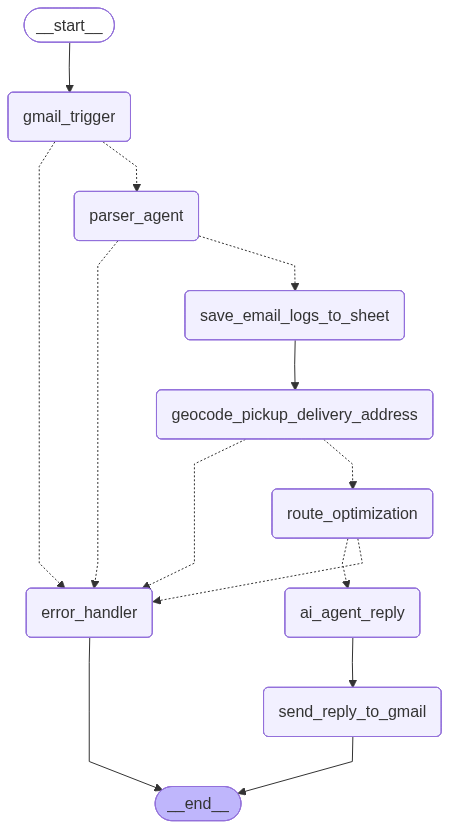

In [13]:
def build_graph():
    builder = StateGraph(LogisticsState)

    builder.add_node('gmail_trigger',                   gmail_trigger)
    builder.add_node('parser_agent',                    parser_agent)
    builder.add_node('save_email_logs_to_sheet',        save_email_logs_to_sheet)
    builder.add_node('geocode_pickup_delivery_address', geocode_pickup_delivery_address)
    builder.add_node('route_optimization',              route_optimization)
    builder.add_node('ai_agent_reply',                  ai_agent_reply)
    builder.add_node('send_reply_to_gmail',             send_reply_to_gmail)
    builder.add_node('error_handler',                   error_handler)

    builder.add_edge(START, 'gmail_trigger')

    builder.add_conditional_edges('gmail_trigger', route_after_trigger,
        {'parser_agent': 'parser_agent', 'error_handler': 'error_handler'})

    builder.add_conditional_edges('parser_agent', route_after_parse,
        {'save_email_logs_to_sheet': 'save_email_logs_to_sheet', 'error_handler': 'error_handler'})

    builder.add_edge('save_email_logs_to_sheet', 'geocode_pickup_delivery_address')

    builder.add_conditional_edges('geocode_pickup_delivery_address', route_after_geocode,
        {'route_optimization': 'route_optimization', 'error_handler': 'error_handler'})

    builder.add_conditional_edges('route_optimization', route_after_optimization,
        {'ai_agent_reply': 'ai_agent_reply', 'error_handler': 'error_handler'})

    builder.add_edge('ai_agent_reply',      'send_reply_to_gmail')
    builder.add_edge('send_reply_to_gmail', END)
    builder.add_edge('error_handler',       END)

    app = builder.compile(checkpointer=MemorySaver())
    log.info('LangGraph compiled: 8 nodes, linear flow.')
    return app


app = build_graph()
app

## Main Polling Loop

In [14]:
from tools.gmail_tools import poll_gmail_inbox

POLL_INTERVAL = int(os.getenv('GMAIL_POLL_INTERVAL', '60'))
GMAIL_QUERY = os.getenv('GMAIL_QUERY', 'is:unread subject:collection request')


def process_email(app, raw_email: str, thread_id: str, sender_email: str) -> dict:
    config = {'configurable': {'thread_id': thread_id}}
    state: LogisticsState = {
        'raw_email_content': raw_email,
        'sender_email': sender_email,
        'thread_id': thread_id,
        'collection_request_id': '',
        'parsed_stops': [],
        'geocoded_stops': [],
        'sender_company': '',
        'route_result': None,
        'reply_html': '',
        'email_log_saved': False,
        'error': None,
    }
    log.info('Processing email from %s (thread: %s)', sender_email, thread_id)
    result = app.invoke(state, config=config)

    if result.get('error'):
        log.error('Workflow failed [%s] for thread %s', result['error'], thread_id)
    else:
        log.info('Done. Reply sent to %s (%s)', sender_email, result.get('collection_request_id', ''))
    return result

def main():
    log.info('Gmail polling every %ds. Query: %r', POLL_INTERVAL, GMAIL_QUERY)
    processed_ids: set = set()

    while True:
        try:
            emails = poll_gmail_inbox.invoke({'query': GMAIL_QUERY})
            new_emails = [e for e in emails if e['message_id'] not in processed_ids]
            if new_emails:
                log.info('Found %d new email(s).', len(new_emails))
            for email in new_emails:
                processed_ids.add(email['message_id'])
                process_email(app, email['body'], email['thread_id'], email['sender_email'])
        except Exception as exc:
            log.exception('Polling error: %s', exc)
        time.sleep(POLL_INTERVAL)


main()

2026-04-12 04:27:48,412 [INFO] Gmail polling every 60s. Query: 'is:unread subject:Pickup Schedule'
2026-04-12 04:27:49,732 [INFO] Found 1 new email(s).
2026-04-12 04:27:49,733 [INFO] Processing email from Anuj Mumbaikar <anuj.mumbaikar05@gmail.com> (thread: 19d7ec3eb67e78b1)
/var/folders/73/489qwk890nz19z7w2q63j4k00000gn/T/ipykernel_68762/4015764096.py:2: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ts = datetime.utcnow()
2026-04-12 04:27:51,527 [INFO] New request: REQ-20260411-cddf05 (thread: 19d7ec3eb67e78b1)
2026-04-12 04:27:55,267 [INFO] HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-04-12 04:27:55,291 [INFO] Parsed 6 stops (sender: Retail Operations)
2026-04-12 04:28:00,706 [INFO] Logs saved: 6 stops for REQ-20260411-cddf05
2026-04-12 04:28:02,426 [INFO] Geocoded pickup stop 1: (18.9891

KeyboardInterrupt: 